In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
from utils import *
import re
import random

In [2]:
#Importing data

train = pd.read_csv("data/train.csv")

In [3]:
#Checking first 5 rows
train.head()

,title,tag,artist,year,views,features,lyrics,id
0,Walk Away,rock,Tony Molina,2013,699,{},When you said you loved me\nDid you mean it th...,535805
1,Gotta Make It Kid Naruto Rap,rap,Reece Lett,2021,4,{Sl!ck},Kid Naruto Rap\n[Hook]\nEverybody wants you to...,7519483
2,​this is what i asked for,pop,Elliot (DNK),2019,389,{},[Verse 1]\nPeople tell me I've changed\nI find...,4892808
3,Stealing Hearts,pop,Katie Armiger,2013,126,{},You've been warned about me\nDon't try to get ...,1584150
4,Get Ready,country,John Campbell Munro,1,2,{},[Verse 1]\nI can see the end is coming but I’v...,7639050


In [4]:
#checking data types
print(train.dtypes)

title       object
tag         object
artist      object
year         int64
views        int64
features    object
lyrics      object
id           int64
dtype: object


In [5]:
#Checking for missing values

train.isna().sum()

title       2
tag         0
artist      0
year        0
views       0
features    0
lyrics      0
id          0
dtype: int64

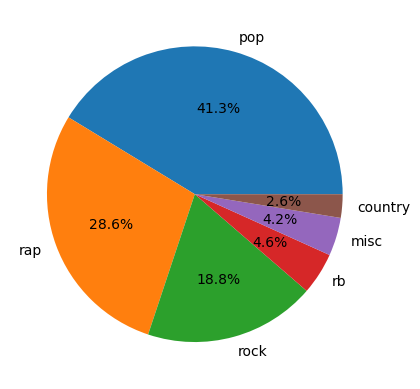

In [6]:
#Looking at target class distribution

genres = train["tag"].value_counts()

plt.pie(x = genres, labels = genres.index, autopct='%1.1f%%')
plt.show()

In [7]:


def show_n_lyrics(df,n,random_state = None):

    """
    Function to show a randomly sampled subset of songs
    """

    rdm = random.Random(random_state)
    indexes =  rdm.sample(range(0, len(df)+1), n)
    counter = 1
    for index in indexes:

        print(f"Song number: {counter}")
        print(ascii(df["lyrics"].iloc[index]))
        print("-"*10)
        counter += 1

In [8]:
show_n_lyrics(train,10,random_state=77)

Song number: 1
"[Chorus]\nStruck a chord like the Tristan\nFeel the tension building if you're listening\nStruck a chord like the Tristan\nWhere I was, where I am now, it\u2019s a mission\nWith a chip on my shoulder\nMourning the death of rap like Isolde\nWith a chip on my shoulder\nCame back to hip hop now I'm much older\n\n\n[VERSE 1]\nSo if you step inside of my dungeon\nDark and dingy like victorian London\nPermanent tracks, I can never be undone\nA microphone, amp and no interruption\n(what we gonna do?)\nDo it if it doesnt cost us\nDoctor doctor, too sick, I'm like Costner\nUntouchable, gonna live long and prosper\nTaking names this is Z with the roster\nNo stopping m\u0435, ain\u2019t no stopping me\nStep in to the r\u0435d room im like whats popping G\nIf I keep dropping these, fire beats probably\nIma need something much stronger than coffee beans\nAye, I'm joking\nNever get caught on the wrong road I promise, I'm a changed man real talk\nIf I had the choice of that shit or ge

<b> Notes </b>

- There are some structural tags contained in square brackets e.g. ([Verse 1])
- Song lyrics have newline (\n) characters
- Detected the presence of homoglyphs (letters in another alphabet that look like ours)
- There are some censured words e.g (b***h)
- The tag column is heavily unbalanced




In [9]:
#Dropping all columns except "tag" and "lyrics", because the genre prediction will be
#based solely on the lyrics
train = train.drop(["title","year","features","artist","id","views"],axis=1)

In [10]:
def search_non_alphanumeric(df):
    """this is a function made with the purpose of
    looking for emojis, unicode characters and other
    characters that are not alphanumeric
    """
    non_alphanumeric = []
    for lyric in df["lyrics"]:
        non_alphanumeric.extend(re.findall("\W",lyric))

    non_alphanumeric = set(non_alphanumeric)
    print(non_alphanumeric)

In [11]:
search_non_alphanumeric(train)

{'↻', '📱', '🇮', '—', '™', '🏕', '*', '‚', '‒', '🍩', '📚', '>', '•', '💧', '🎉', '₥', '👺', 'ึ', '🍊', '❌', '🚗', '้', '😷', '´', '/', '🪝', '❓', '🤷', '🚂', '☞', '%', '￫', '¶', '‐', '🥵', '🐂', '🏱', '🌧', '¬', '✰', '🇸', '♤', '\x96', ':', '◥', '،', '🎠', 'ె', '·', '…', '💶', '℠', '¦', '💥', '\u2028', '̄', '；', '🤪', '–', '🏾', '👉', '\u2009', '￩', '☮', '🛸', '\u3000', '@', '🛑', '🚒', '❍', '🍑', '🐊', '🇱', '‛', '🍞', '⚡', '̵', '📅', '😘', '🤬', '\u205f', '„', '🗣', '√', '❏', '。', '🇺', '͠', '♧', '📯', '💇', '≤', '✌', '🖕', '↗', '♀', '💓', 'ี', '☂', '🎩', '=', '😃', '🙂', '\u200e', '❗', '״', '）', '∩', '🍎', '？', '-', '💐', '▓', '‘', '℗', '😱', '､', '🙅', '👁', '\u2063', '□', '👅', '🖐', '\t', '👯', '✅', '『', '❛', '\u202a', '˜', '‽', '█', '💵', '“', '👆', 'ื', '✒', '¢', '$', '😭', '▪', 'ّ', '₦', '🙏', '∞', '🎣', '👿', '♡', '¡', '～', '🌹', '😊', '¨', '[', '：', '💿', '\xa0', '👀', '🏚', '\x9b', '🇩', '\\', '✦', '\u200c', '¿', '"', '\x9d', '≈', '―', '±', '🐚', ']', '″', '❤', '`', '☔', '✔', '^', '₮', '😅', '÷', '☣', '🛏', '🌀', 'ి', '®', '🕆', '😂', '”', 

In [12]:
teste = train.copy()

In [13]:

def search_boiler_plate(df,patterns):

    """
    Detects the presence of any Genius boiler plate tags 
    in any song
    prints Y if 1 more songs contain the regex pattern being searched
    prints N if 0 songs contain the regex pattern being searched
    """

    for pattern in patterns:
        flag = False
        for lyric in df["lyrics"]:
            if re.findall(pattern, lyric):
                flag = True
                print(f"{pattern} : Y")
                break
        
        if not flag:
            print(f"{pattern} : N")
        


In [17]:
search_boiler_plate(train,[
    r"(?im)^\d+\s*Contributors?.*$",         
    r"(?m)^.*?Lyrics\s*$",                     
    r"(?i)\bEmbed\b",                          
    r"(?i)You might also like",
    r"(?m)^\d+$", 
    r"(?im)^(verse|chorus|intro|outro|bridge|pre-chorus|hook|interlude)\b.*?:",
    r"\[.*?\]",
    r"(?i)\(\s*x\s*\d+\s*\)",
    r"\[\d{2}:\d{2}(?:\.\d{2,3})?\]"
])

(?im)^\d+\s*Contributors?.*$ : Y
(?m)^.*?Lyrics\s*$ : Y
(?i)\bEmbed\b : Y
(?i)You might also like : N
(?m)^\d+$ : Y
(?im)^(verse|chorus|intro|outro|bridge|pre-chorus|hook|interlude)\b.*?: : Y
\[.*?\] : Y
(?i)\(\s*x\s*\d+\s*\) : Y
\[\d{2}:\d{2}(?:\.\d{2,3})?\] : Y


In [15]:
teste["lyrics"] = teste["lyrics"].apply(preprocess_text)

In [16]:
show_n_lyrics(teste,10,random_state=77)

Song number: 1
" struck a chord like the tristan feel the tension building if you're listening struck a chord like the tristan where i was where i am now it's a mission with a chip on my shoulder mourning the death of rap like isolde with a chip on my shoulder came back to hip hop now i'm much older so if you step inside of my dungeon dark and dingy like victorian london permanent tracks i can never be undone a microphone amp and no interruption what we gonna do do it if it doesnt cost us doctor doctor too sick i'm like costner untouchable gonna live long and prosper taking names this is z with the roster no stopping me ain't no stopping me step in to the red room im like whats popping g if i keep dropping these fire beats probably ima need something much stronger than coffee beans aye i'm joking never get caught on the wrong road i promise i'm a changed man real talk if i had the choice of that shit or get straight be creative trust me nothing would appeal more struck a chord like the